In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
# Normalize (VERY IMPORTANT)
x_train, x_test = x_train / 255.0, x_test / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [8]:
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

In [13]:
def build_model(activation):
    model = models.Sequential([

        layers.Conv2D(32, (3,3), activation=activation, input_shape=(28,28,1)),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation=activation),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation=activation),

        layers.Flatten(),
        layers.Dense(64, activation=activation),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [14]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [15]:
model = build_model('relu')

history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 42ms/step - accuracy: 0.8188 - loss: 0.4968 - val_accuracy: 0.8685 - val_loss: 0.3632
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.8829 - loss: 0.3191 - val_accuracy: 0.8831 - val_loss: 0.3222
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9003 - loss: 0.2712 - val_accuracy: 0.8966 - val_loss: 0.2858
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - accuracy: 0.9125 - loss: 0.2391 - val_accuracy: 0.8971 - val_loss: 0.2820
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9197 - loss: 0.2186 - val_accuracy: 0.9040 - val_loss: 0.2698
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9260 - loss: 0.1985 - val_accuracy: 0.9052 - val_loss: 0.2610
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9330 - loss: 0.1819 - val_accuracy: 0.9076 - val_loss: 0.2605
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9383 -

In [16]:
from sklearn.metrics import classification_report

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = y_test.flatten()

print(classification_report(y_true, y_pred_classes, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
              precision    recall  f1-score   support

     T-shirt       0.79      0.90      0.84      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.80      0.90      0.85      1000
       Dress       0.93      0.91      0.92      1000
        Coat       0.88      0.82      0.85      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.78      0.64      0.70      1000
     Sneaker       0.97      0.95      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.95      0.97      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



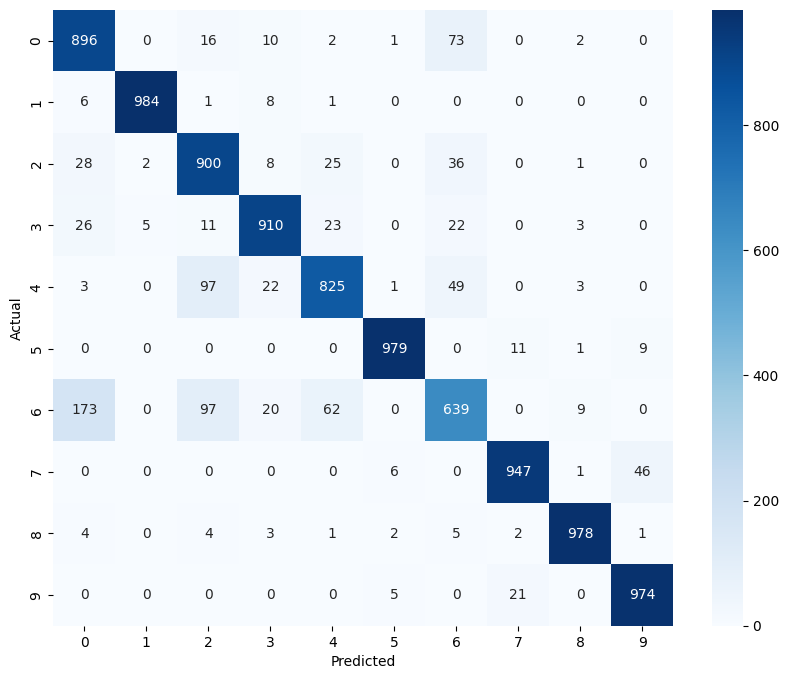

In [17]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Fashion MNIST")
plt.show()

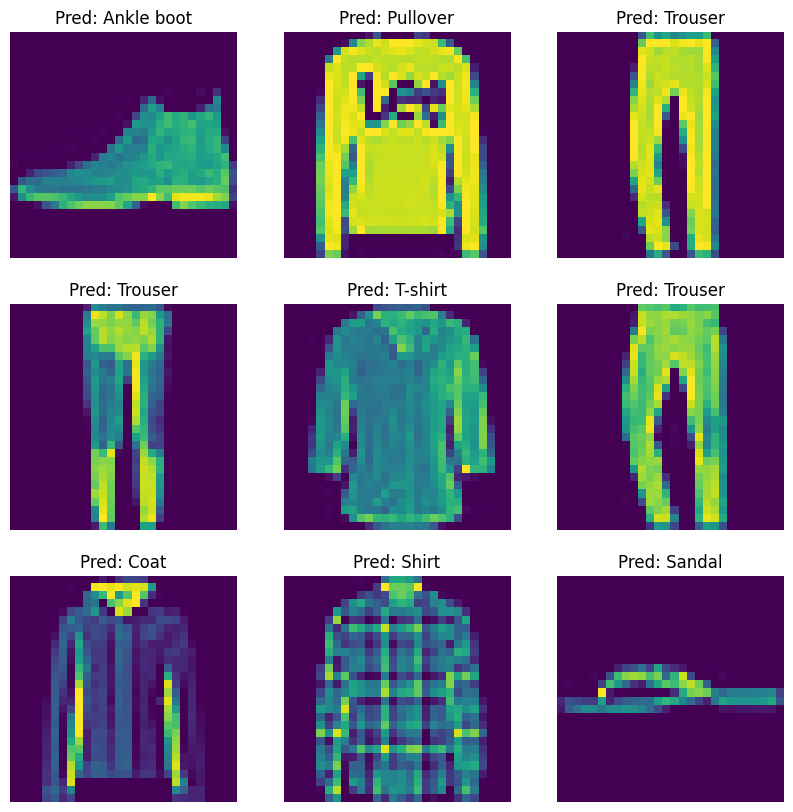

In [18]:
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_test[i])
    plt.title(f"Pred: {class_names[y_pred_classes[i]]}")
    plt.axis('off')
plt.show()

In [19]:
model_sigmoid = build_model('sigmoid')
history_sigmoid = model_sigmoid.fit(x_train, y_train, epochs=10,
                                   validation_data=(x_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.6579 - loss: 0.9192 - val_accuracy: 0.7662 - val_loss: 0.6202
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.7999 - loss: 0.5321 - val_accuracy: 0.8117 - val_loss: 0.5075
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.8341 - loss: 0.4449 - val_accuracy: 0.8340 - val_loss: 0.4466
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.8539 - loss: 0.3955 - val_accuracy: 0.8466 - val_loss: 0.4096
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 87s 31ms/step - accuracy: 0.8651 - loss: 0.3620 - val_accuracy: 0.8503 - val_loss: 0.3925
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.8729 - loss: 0.3403 - val_accuracy: 0.8577 - val_loss: 0.3705
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.8805 - loss: 0.3208 - val_accuracy: 0.8691 - val_loss: 0.3544
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.8856 -

In [20]:
ys_pred = model_sigmoid.predict(x_test)
ys_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, ys_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
              precision    recall  f1-score   support

           0       0.79      0.90      0.84      1000
           1       0.99      0.98      0.99      1000
           2       0.80      0.90      0.85      1000
           3       0.93      0.91      0.92      1000
           4       0.88      0.82      0.85      1000
           5       0.98      0.98      0.98      1000
           6       0.78      0.64      0.70      1000
           7       0.97      0.95      0.96      1000
           8       0.98      0.98      0.98      1000
           9       0.95      0.97      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



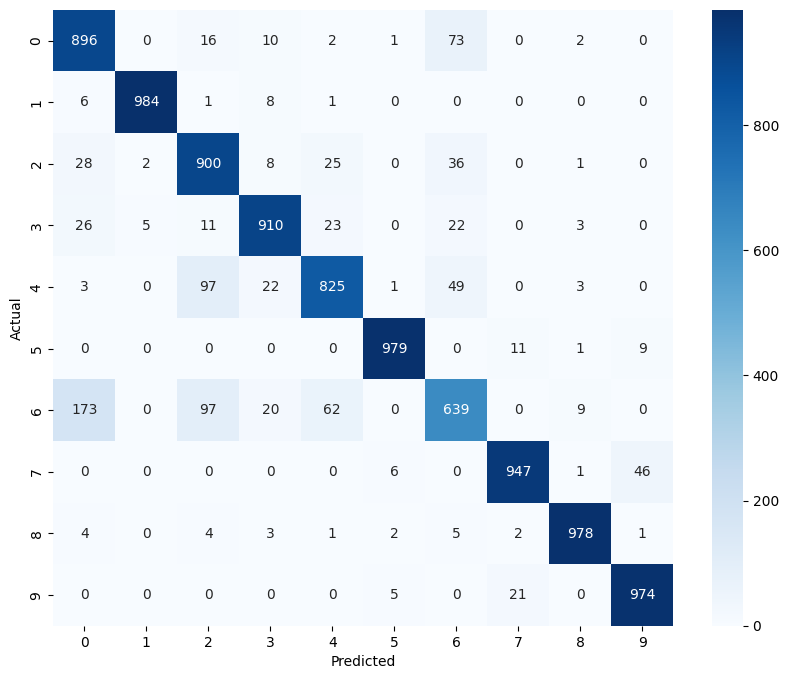

In [21]:
cm = confusion_matrix(y_test, ys_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
model_tanh = build_model('tanh')
history_tanh = model_tanh.fit(x_train, y_train, epochs=10,
                             validation_data=(x_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.8304 - loss: 0.4642 - val_accuracy: 0.8714 - val_loss: 0.3561
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.8841 - loss: 0.3188 - val_accuracy: 0.8804 - val_loss: 0.3284
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 32ms/step - accuracy: 0.8984 - loss: 0.2819 - val_accuracy: 0.8870 - val_loss: 0.3123
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 30ms/step - accuracy: 0.9061 - loss: 0.2560 - val_accuracy: 0.8950 - val_loss: 0.2956
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9134 - loss: 0.2354 - val_accuracy: 0.8921 - val_loss: 0.2952
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9216 - loss: 0.2173 - val_accuracy: 0.9069 - val_loss: 0.2725
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 30ms/step - accuracy: 0.9261 - loss: 0.2012 - val_accuracy: 0.9006 - val_loss: 0.2839
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9305 -

In [23]:
yt_pred = model_sigmoid.predict(x_test)
yt_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, yt_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
              precision    recall  f1-score   support

           0       0.79      0.90      0.84      1000
           1       0.99      0.98      0.99      1000
           2       0.80      0.90      0.85      1000
           3       0.93      0.91      0.92      1000
           4       0.88      0.82      0.85      1000
           5       0.98      0.98      0.98      1000
           6       0.78      0.64      0.70      1000
           7       0.97      0.95      0.96      1000
           8       0.98      0.98      0.98      1000
           9       0.95      0.97      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



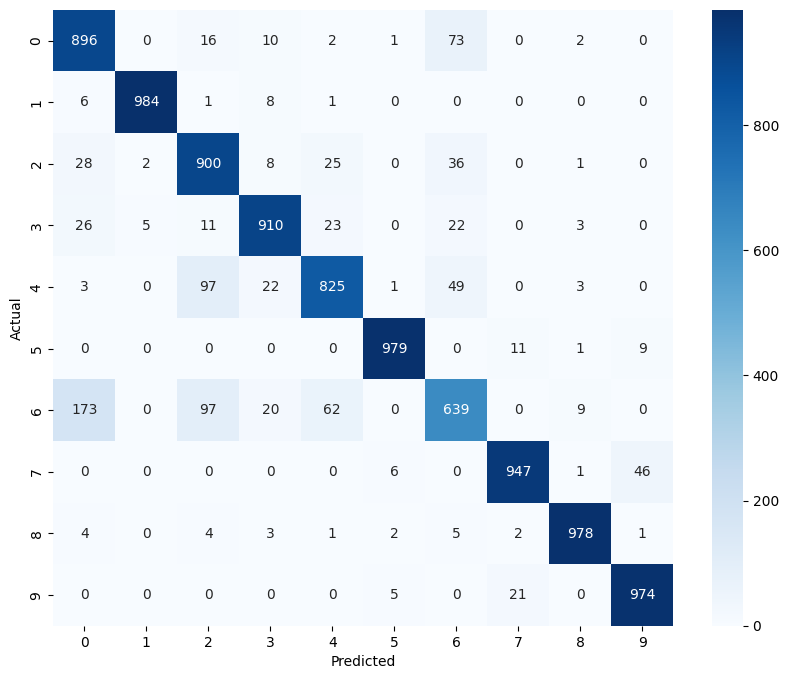

In [24]:
cm = confusion_matrix(y_test, yt_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

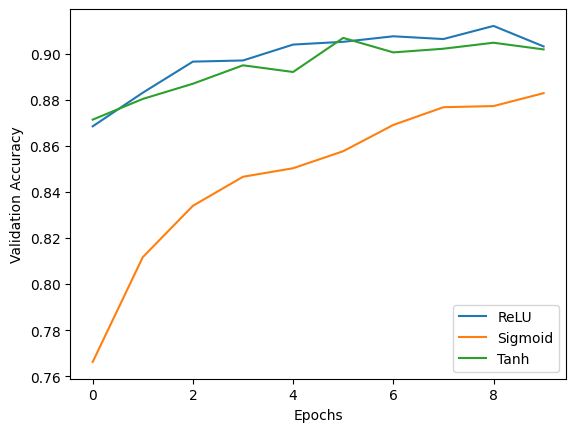

In [25]:
plt.plot(history.history['val_accuracy'], label='ReLU')
plt.plot(history_sigmoid.history['val_accuracy'], label='Sigmoid')
plt.plot(history_tanh.history['val_accuracy'], label='Tanh')

plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

In [26]:
print("Sigmoid Accuracy:", model_sigmoid.evaluate(x_test, y_test)[1])

print("ReLU Accuracy:", model.evaluate(x_test, y_test)[1])

print("Tanh Accuracy:", model_tanh.evaluate(x_test, y_test)[1])


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8829 - loss: 0.3124
Sigmoid Accuracy: 0.8828999996185303
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9032 - loss: 0.2905
ReLU Accuracy: 0.9031999707221985
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9019 - loss: 0.2816
Tanh Accuracy: 0.9018999934196472


In [27]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Flatten true labels
y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [28]:
from sklearn.metrics import classification_report

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

report = classification_report(y_true, y_pred_classes, target_names=class_names)

print(report)

              precision    recall  f1-score   support

    airplane       0.79      0.90      0.84      1000
  automobile       0.99      0.98      0.99      1000
        bird       0.80      0.90      0.85      1000
         cat       0.93      0.91      0.92      1000
        deer       0.88      0.82      0.85      1000
         dog       0.98      0.98      0.98      1000
        frog       0.78      0.64      0.70      1000
       horse       0.97      0.95      0.96      1000
        ship       0.98      0.98      0.98      1000
       truck       0.95      0.97      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

